# Portable Laptop QC + Analysis Notebook

This notebook is for **local inspection of HPC outputs** after you copy down the exported
`portable_laptop_bundle` folder from the cluster.

It is designed to:

- load exported tables and mask hyperstacks
- open the outputs in **napari**
- plot the main analysis results
- support light QC without rerunning the heavy model steps

## Expected bundle layout

```text
portable_laptop_bundle/
├── manifest.json
├── config/
│   └── pipeline_config.json
├── masks/
│   ├── segmentation_class_hyperstack.tif
│   ├── segmentation_label_hyperstack.tif
│   ├── nucleus_instance_hyperstack.tif
│   └── droplet_instance_hyperstack.tif
├── tables/
│   ├── best_z_nuclei.*
│   ├── best_z_nuclei_timed.*
│   ├── tracked_nuclei.*
│   ├── halo_analysis.*
│   └── ...
└── notes/
    └── README.txt
```

## Notes

- This notebook **does not rerun U-Net**.
- If you also want to overlay the **raw image**, either:
  - copy the raw TIFF locally and set `RAW_IMAGE_PATH`, or
  - place it somewhere accessible on your laptop and point the notebook to it.
- If probability maps were not exported, the notebook will skip them automatically.

In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 120

## 1. Set local paths

Update `BUNDLE_DIR` to the copied export folder on your laptop.

If you also copied the original raw TIFF locally, set `RAW_IMAGE_PATH`.
Otherwise leave it as `None`.

In [2]:

# --- USER SETTINGS ---
BUNDLE_DIR = Path(r"C:/Users/cowboy/OneDrive/Documents/University of Alabama/Nuclear_Scaling/Data_Sets/Control/portable_laptop_bundle")
RAW_IMAGE_PATH = Path(r"C:/Users/cowboy/OneDrive/Documents/University of Alabama/Nuclear_Scaling/Data_Sets/Control/Extract_1/control_extract_1.tif")  # Example: Path(r"C:/Users/cowboy/.../control_extract_1.1.tif")
AUTO_OPEN_NAPARI = False

## 2. Helper functions

In [3]:

def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)

def first_existing(path_options):
    for p in path_options:
        if p is not None and Path(p).exists():
            return Path(p)
    return None

def load_table_prefer_parquet_csv_pickle(stem: Path):
    parquet_path = stem.with_suffix(".parquet")
    csv_path = stem.with_suffix(".csv")
    pkl_path = stem.with_suffix(".pkl")

    if parquet_path.exists():
        return pd.read_parquet(parquet_path), parquet_path
    if csv_path.exists():
        return pd.read_csv(csv_path), csv_path
    if pkl_path.exists():
        return pd.read_pickle(pkl_path), pkl_path

    return None, None

def safe_read_tiff(path: Path):
    if path is None or not Path(path).exists():
        return None
    return tiff.imread(path)

def normalize_image(arr: np.ndarray):
    arr = arr.astype(np.float32)
    if arr.size == 0:
        return arr
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if arr_max > arr_min:
        arr = (arr - arr_min) / (arr_max - arr_min)
    return arr

def describe_df(df: pd.DataFrame, name: str):
    if df is None:
        print(f"{name}: missing")
        return
    print(f"{name}: shape={df.shape}")
    print(f"Columns: {list(df.columns)}")
    display(df.head())

def add_time_columns_if_missing(df: pd.DataFrame, cfg: dict):
    if df is None or df.empty:
        return df

    minutes_per_tile = cfg.get("minutes_per_tile", None)
    tile_rows = cfg.get("tile_rows", None)
    tile_cols = cfg.get("tile_cols", None)

    if "true_time_min" not in df.columns and "t" in df.columns and minutes_per_tile is not None:
        if tile_rows is not None and tile_cols is not None:
            tiles_per_cycle = max(int(tile_rows) * int(tile_cols), 1)
        else:
            tiles_per_cycle = 1
        df = df.copy()
        df["true_time_min"] = df["t"] * float(minutes_per_tile) * tiles_per_cycle

    return df

## 3. Load manifest, config, tables, and masks

In [4]:

bundle_dir = BUNDLE_DIR
assert bundle_dir.exists(), f"Bundle directory not found: {bundle_dir}"

manifest_path = bundle_dir / "manifest.json"
config_path = bundle_dir / "config" / "pipeline_config.json"
tables_dir = bundle_dir / "tables"
masks_dir = bundle_dir / "masks"

manifest = load_json(manifest_path) if manifest_path.exists() else {}
config = load_json(config_path) if config_path.exists() else {}

print("Bundle directory:", bundle_dir.resolve())
print("Manifest found:", manifest_path.exists())
print("Config found:", config_path.exists())

Bundle directory: C:\Users\cowboy\OneDrive\Documents\University of Alabama\Nuclear_Scaling\Data_Sets\Control\portable_laptop_bundle
Manifest found: True
Config found: True


In [ ]:
MIN_NUCLEUS_AREA_UM2 = 100
MAX_NUCLEUS_AREA_UM2 = 500
EDGE_BUFFER_PX = 10

In [ ]:

table_names = [
    "segmentation_index",
    "segmentation_index_portable",
    "plane_objects",
    "grouped_z_objects",
    "best_z_nuclei",
    "best_z_nuclei_with_exclusion",
    "best_z_nuclei_timed",
    "tracked_nuclei",
    "halo_analysis",
]

tables = {}
table_sources = {}

for name in table_names:
    df, src = load_table_prefer_parquet_csv_pickle(tables_dir / name)
    tables[name] = df
    table_sources[name] = src

seg_index_df = tables["segmentation_index_portable"] if tables["segmentation_index_portable"] is not None else tables["segmentation_index"]
objects_df = tables["plane_objects"]
grouped_z_df = tables["grouped_z_objects"]
best_z_df = tables["best_z_nuclei"]
filtered_df = tables["best_z_nuclei_with_exclusion"]
timed_df = tables["best_z_nuclei_timed"]
tracked_df = tables["tracked_nuclei"]
halo_df = tables["halo_analysis"]

for key in ["best_z_nuclei", "best_z_nuclei_timed", "tracked_nuclei", "halo_analysis"]:
    if tables[key] is not None:
        tables[key] = add_time_columns_if_missing(tables[key], config)

best_z_df = best_z_df[
    (best_z_df["nucleus_area_um2"] >= MIN_NUCLEUS_AREA_UM2) &
    (best_z_df["nucleus_area_um2"] <= MAX_NUCLEUS_AREA_UM2)
].copy()
timed_df = tables["best_z_nuclei_timed"]
tracked_df = tables["tracked_nuclei"]
halo_df = tables["halo_analysis"]

In [6]:

mask_files = {
    "segmentation_class": first_existing([
        masks_dir / "segmentation_class_hyperstack.tif",
    ]),
    "segmentation_label": first_existing([
        masks_dir / "segmentation_label_hyperstack.tif",
    ]),
    "nucleus_instance": first_existing([
        masks_dir / "nucleus_instance_hyperstack.tif",
    ]),
    "droplet_instance": first_existing([
        masks_dir / "droplet_instance_hyperstack.tif",
    ]),
    "segmentation_prob": first_existing([
        masks_dir / "segmentation_prob_hyperstack.tif",   # future-proof if added later
        masks_dir / "probability_hyperstack.tif",
    ]),
}

mask_arrays = {name: safe_read_tiff(path) for name, path in mask_files.items()}

raw_img = safe_read_tiff(Path(RAW_IMAGE_PATH)) if RAW_IMAGE_PATH is not None else None

## 4. Quick bundle summary

In [7]:

print("=== TABLES ===")
for name, src in table_sources.items():
    exists = src is not None
    print(f"{name:30s} -> {'loaded from ' + str(src.name) if exists else 'missing'}")

print("\n=== MASKS ===")
for name, path in mask_files.items():
    arr = mask_arrays[name]
    shape = None if arr is None else arr.shape
    print(f"{name:30s} -> {path.name if path else 'missing'} | shape={shape}")

print("\n=== RAW IMAGE ===")
print("raw image loaded:", raw_img is not None)
if raw_img is not None:
    print("raw image shape:", raw_img.shape)

=== TABLES ===
segmentation_index             -> loaded from segmentation_index.csv
segmentation_index_portable    -> missing
plane_objects                  -> loaded from plane_objects.csv
grouped_z_objects              -> loaded from grouped_z_objects.csv
best_z_nuclei                  -> loaded from best_z_nuclei.csv
best_z_nuclei_with_exclusion   -> loaded from best_z_nuclei_with_exclusion.csv
best_z_nuclei_timed            -> loaded from best_z_nuclei_timed.csv
tracked_nuclei                 -> loaded from tracked_nuclei.csv
halo_analysis                  -> loaded from halo_analysis.csv

=== MASKS ===
segmentation_class             -> segmentation_class_hyperstack.tif | shape=(10, 20, 3, 3889, 5732)
segmentation_label             -> segmentation_label_hyperstack.tif | shape=(10, 20, 3889, 5732)
nucleus_instance               -> nucleus_instance_hyperstack.tif | shape=(10, 20, 3889, 5732)
droplet_instance               -> droplet_instance_hyperstack.tif | shape=(10, 20, 3889, 5732

## 5. Inspect main tables

In [8]:

describe_df(best_z_df, "best_z_df")
describe_df(tracked_df, "tracked_df")
describe_df(halo_df, "halo_df")

best_z_df: shape=(19443, 12)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'true_time_min']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,true_time_min
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,1,0.0
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,2,0.0
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,3,0.0
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,4,0.0
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,5,0.0


tracked_df: shape=(19443, 25)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'valid_single_nucleus', 'tile_row', 'tile_col', 'tile_index', 'tile_offset_min', 'true_time_min', 'global_index', 'track_id', 'track_link_distance_px', 'track_link_cost', 'track_dbscan_cluster_id', 'track_dbscan_cluster_size', 'track_dbscan_is_crowded', 'track_link_method']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,tile_offset_min,true_time_min,global_index,track_id,track_link_distance_px,track_link_cost,track_dbscan_cluster_id,track_dbscan_cluster_size,track_dbscan_is_crowded,track_link_method
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,...,1.0,1.0,0,1,NaN,NaN,-1,0,False,seed
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,...,0.0,0.0,1,2,NaN,NaN,-1,0,False,seed
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,...,2.0,2.0,2,3,NaN,NaN,-1,0,False,seed
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,...,2.0,2.0,3,4,NaN,NaN,-1,0,False,seed
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,...,1.0,1.0,4,5,NaN,NaN,-1,0,False,seed


halo_df: shape=(19443, 62)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'valid_single_nucleus', 'tile_row', 'tile_col', 'tile_index', 'tile_offset_min', 'true_time_min', 'global_index', 'track_id', 'track_link_distance_px', 'track_link_cost', 'track_dbscan_cluster_id', 'track_dbscan_cluster_size', 'track_dbscan_is_crowded', 'track_link_method', 'nucleus_area_px', 'nucleus_intden', 'nucleus_mean_intensity', 'nucleus_eroded_area_px', 'nucleus_eroded_intden', 'nucleus_eroded_mean_intensity', 'halo_1_cum_area_px', 'halo_1_cum_intden', 'halo_1_cum_mean_intensity', 'halo_2_cum_area_px', 'halo_2_cum_intden', 'halo_2_cum_mean_intensity', 'halo_3_cum_area_px', 'halo_3_cum_intden', 'halo_3_cum_mean_intensity', 'halo_4_cum_area_px', 'halo_4_cum_intden', 'halo_4_cum_mean_intensity', 'ring_1_area_px', 'ring_1_intden', 'ring_1_mean_intensity', 'ring_2_area_px', 'ring_2_intden', 'ring_2_mean_

,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,ring_4_area_px,ring_4_intden,ring_4_mean_intensity,cytoplasm_area_px,cytoplasm_intden,cytoplasm_mean_intensity,nc_ratio,nc_ratio_fraction,nucleus_area_um2,cytoplasm_area_um2
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,...,1721,345047.0,200.492156,6756,1474269.0,218.216252,1.476644,0.596228,201.029040,78.801984
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,...,1851,349774.0,188.964884,7402,1479931.0,199.936639,1.324211,0.569747,178.050960,86.336928
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,...,1954,372813.0,190.794780,7986,1626352.0,203.650388,1.386602,0.580994,198.719568,93.148704
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,...,1509,404265.0,267.902584,6137,1778566.0,289.810331,1.205070,0.546500,99.085680,71.581968
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,...,2072,466620.0,225.202703,7670,1848205.0,240.965450,1.319510,0.568875,147.397968,89.462880


## 6. Plot helpers

In [9]:

def plot_counts_by_time(df: pd.DataFrame, title="Object count by time"):
    if df is None or df.empty or "t" not in df.columns:
        print("Missing required table/column for counts-by-time plot.")
        return

    plot_df = df.copy()
    if "true_time_min" in plot_df.columns:
        x = plot_df.groupby("true_time_min").size().reset_index(name="count")
        xlabel = "True time (min)"
        xcol = "true_time_min"
    else:
        x = plot_df.groupby("t").size().reset_index(name="count")
        xlabel = "Time index"
        xcol = "t"

    plt.figure()
    plt.plot(x[xcol], x["count"], marker="o")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_area_distribution(df: pd.DataFrame, area_col="area_px", title="Area distribution"):
    if df is None or df.empty or area_col not in df.columns:
        print(f"Missing required column: {area_col}")
        return

    vals = pd.to_numeric(df[area_col], errors="coerce").dropna()
    if vals.empty:
        print("No valid values to plot.")
        return

    plt.figure()
    plt.hist(vals, bins=40)
    plt.xlabel(area_col)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_area_vs_time(df: pd.DataFrame, area_col_candidates=("nucleus_area_um2", "area_um2", "area_px"), group_col="track_id"):
    if df is None or df.empty:
        print("No data to plot.")
        return

    area_col = next((c for c in area_col_candidates if c in df.columns), None)
    if area_col is None:
        print("No supported area column found.")
        return

    xcol = "true_time_min" if "true_time_min" in df.columns else ("t" if "t" in df.columns else None)
    if xcol is None:
        print("No time column found.")
        return

    plt.figure()
    if group_col in df.columns:
        for gid, sub in df.groupby(group_col):
            sub = sub.sort_values(xcol)
            plt.plot(sub[xcol], sub[area_col], marker="o", label=str(gid))
    else:
        sub = df.sort_values(xcol)
        plt.plot(sub[xcol], sub[area_col], marker="o")

    plt.xlabel("True time (min)" if xcol == "true_time_min" else "Time index")
    plt.ylabel(area_col)
    plt.title(f"{area_col} vs time")
    plt.tight_layout()
    plt.show()

def plot_nc_vs_time(halo_df: pd.DataFrame, y_col="nc_ratio_fraction", group_col="track_id"):
    if halo_df is None or halo_df.empty:
        print("No halo data to plot.")
        return
    if y_col not in halo_df.columns:
        print(f"Column not found: {y_col}")
        return

    xcol = "true_time_min" if "true_time_min" in halo_df.columns else ("t" if "t" in halo_df.columns else None)
    if xcol is None:
        print("No time column found.")
        return

    plt.figure()
    if group_col in halo_df.columns:
        for gid, sub in halo_df.groupby(group_col):
            sub = sub.sort_values(xcol)
            plt.plot(sub[xcol], sub[y_col], marker="o", label=str(gid))
    else:
        sub = halo_df.sort_values(xcol)
        plt.plot(sub[xcol], sub[y_col], marker="o")

    plt.xlabel("True time (min)" if xcol == "true_time_min" else "Time index")
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs time")
    plt.tight_layout()
    plt.show()

def plot_metric_histogram(df: pd.DataFrame, col: str, bins=40):
    if df is None or df.empty or col not in df.columns:
        print(f"Missing required column: {col}")
        return

    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    if vals.empty:
        print("No valid values to plot.")
        return

    plt.figure()
    plt.hist(vals, bins=bins)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"{col} distribution")
    plt.tight_layout()
    plt.show()

def summarize_time_table(df: pd.DataFrame, name: str):
    if df is None or df.empty:
        print(f"{name}: empty or missing")
        return

    print(f"\n{name}")
    print("-" * len(name))
    if "t" in df.columns:
        print("n timepoints:", df["t"].nunique())
        print("time range:", int(df["t"].min()), "to", int(df["t"].max()))
    if "track_id" in df.columns:
        print("n tracks:", df["track_id"].nunique())
    if "label" in df.columns:
        print("n labels:", df["label"].nunique())
    print("rows:", len(df))

## 7. Summary stats

In [10]:

summarize_time_table(best_z_df, "best_z_df")
summarize_time_table(timed_df, "timed_df")
summarize_time_table(tracked_df, "tracked_df")
summarize_time_table(halo_df, "halo_df")


best_z_df
---------
n timepoints: 10
time range: 0 to 9
n labels: 222
rows: 19443

timed_df
--------
n timepoints: 10
time range: 0 to 9
n labels: 222
rows: 19443

tracked_df
----------
n timepoints: 10
time range: 0 to 9
n tracks: 19443
n labels: 222
rows: 19443

halo_df
-------
n timepoints: 10
time range: 0 to 9
n tracks: 19443
n labels: 222
rows: 19443


## 8. Core plots

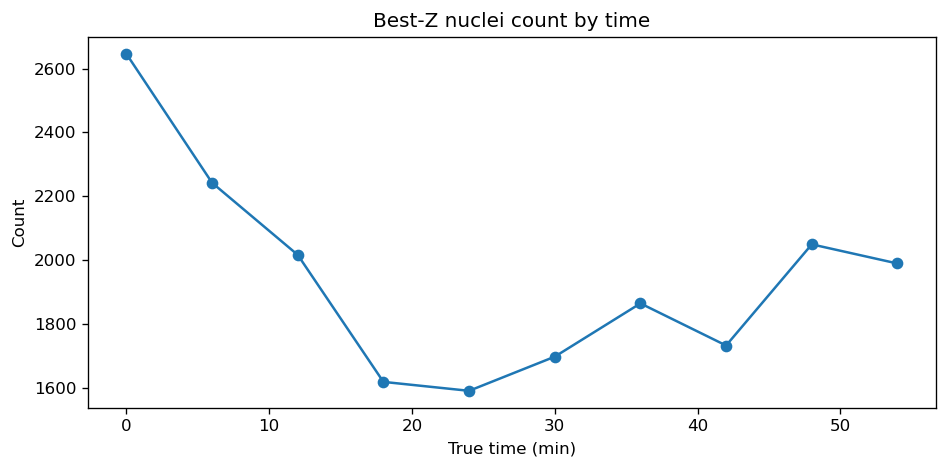

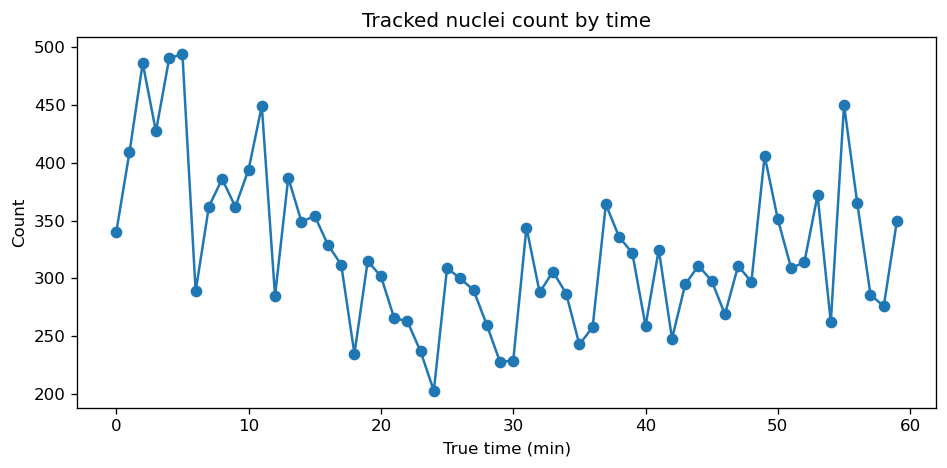

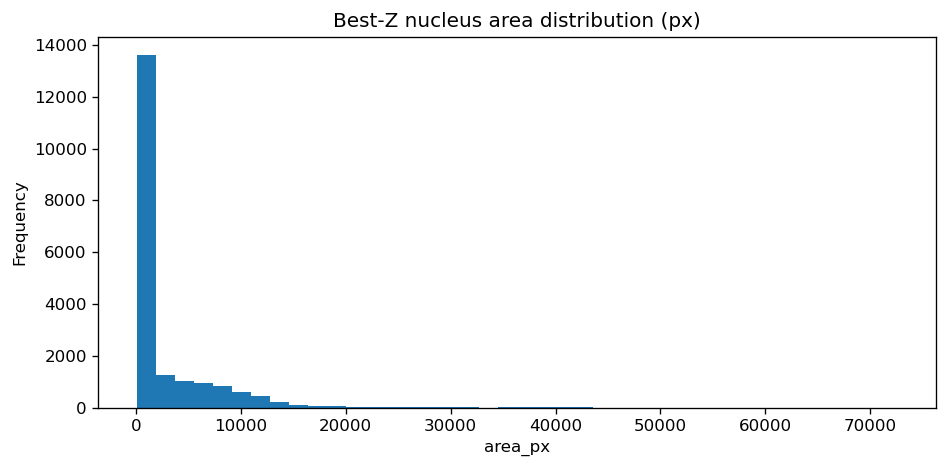

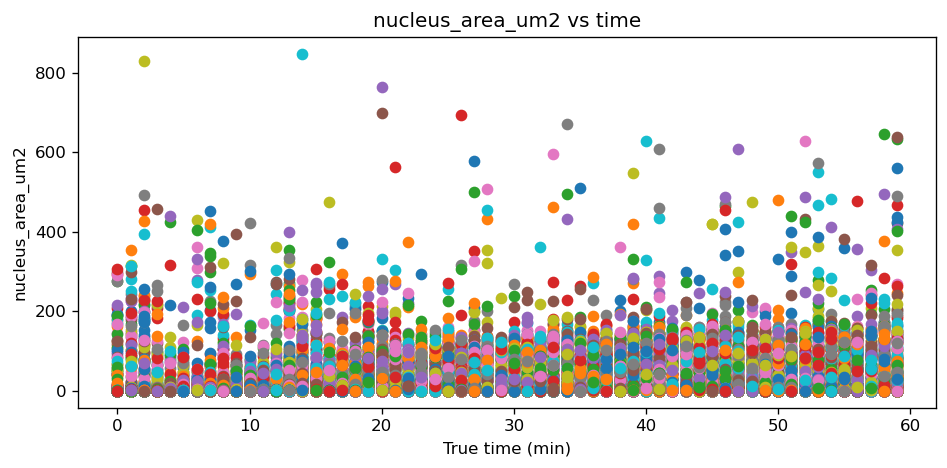

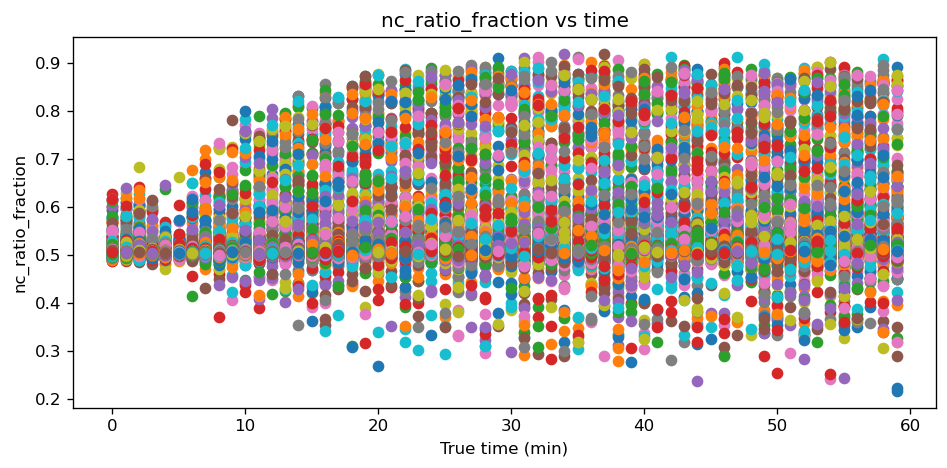

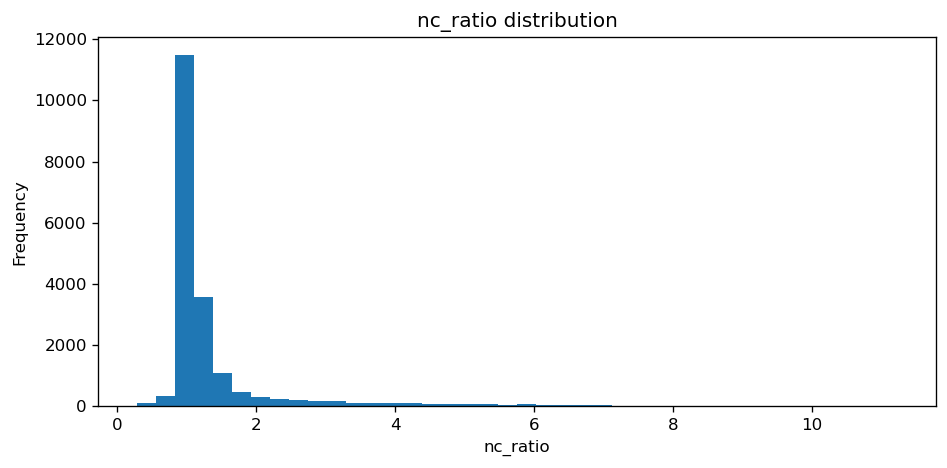

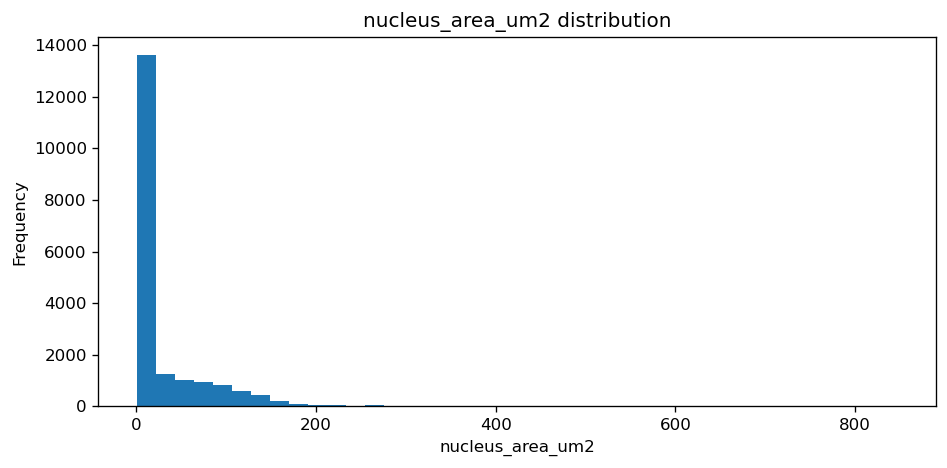

In [11]:

plot_counts_by_time(best_z_df, "Best-Z nuclei count by time")
plot_counts_by_time(tracked_df, "Tracked nuclei count by time")

plot_area_distribution(best_z_df, area_col="area_px", title="Best-Z nucleus area distribution (px)")
plot_area_vs_time(halo_df if halo_df is not None else tracked_df)

if halo_df is not None:
    plot_nc_vs_time(halo_df, y_col="nc_ratio_fraction")
    if "nc_ratio" in halo_df.columns:
        plot_metric_histogram(halo_df, "nc_ratio")
    if "nucleus_area_um2" in halo_df.columns:
        plot_metric_histogram(halo_df, "nucleus_area_um2")

## 9. QC overlay plotting

This works best if you also provide the local raw image path.  
Without the raw image, you can still inspect masks directly in napari.

In [14]:

def choose_z_for_time(mask_4d: np.ndarray, t_idx: int, mode: str = "max_mask") -> int:
    z_count = mask_4d.shape[1]
    if mode == "middle":
        return z_count // 2
    if mode == "max_mask":
        z_sums = mask_4d[t_idx].reshape(z_count, -1).sum(axis=1)
        return int(np.argmax(z_sums))
    raise ValueError("mode must be 'middle' or 'max_mask'")

def plot_raw_and_mask_overlay(raw_5d: np.ndarray, mask_4d: np.ndarray, channel_index: int, timepoints=None, z_mode="max_mask", max_cols=4):
    if raw_5d is None:
        print("Raw image not loaded.")
        return
    if mask_4d is None:
        print("Mask not loaded.")
        return

    T = raw_5d.shape[0]
    if timepoints is None:
        n_show = min(T, 6)
        timepoints = np.linspace(0, T - 1, n_show, dtype=int).tolist()

    n_panels = len(timepoints)
    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, t_idx in zip(axes, timepoints):
        z_idx = choose_z_for_time(mask_4d, t_idx, mode=z_mode)
        raw_plane = normalize_image(raw_5d[t_idx, z_idx, channel_index])
        mask_plane = mask_4d[t_idx, z_idx] > 0

        ax.imshow(raw_plane, cmap="gray")
        ax.imshow(mask_plane, alpha=0.35)
        ax.set_title(f"t={t_idx}, z={z_idx}")
        ax.axis("off")

    for ax in axes[n_panels:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

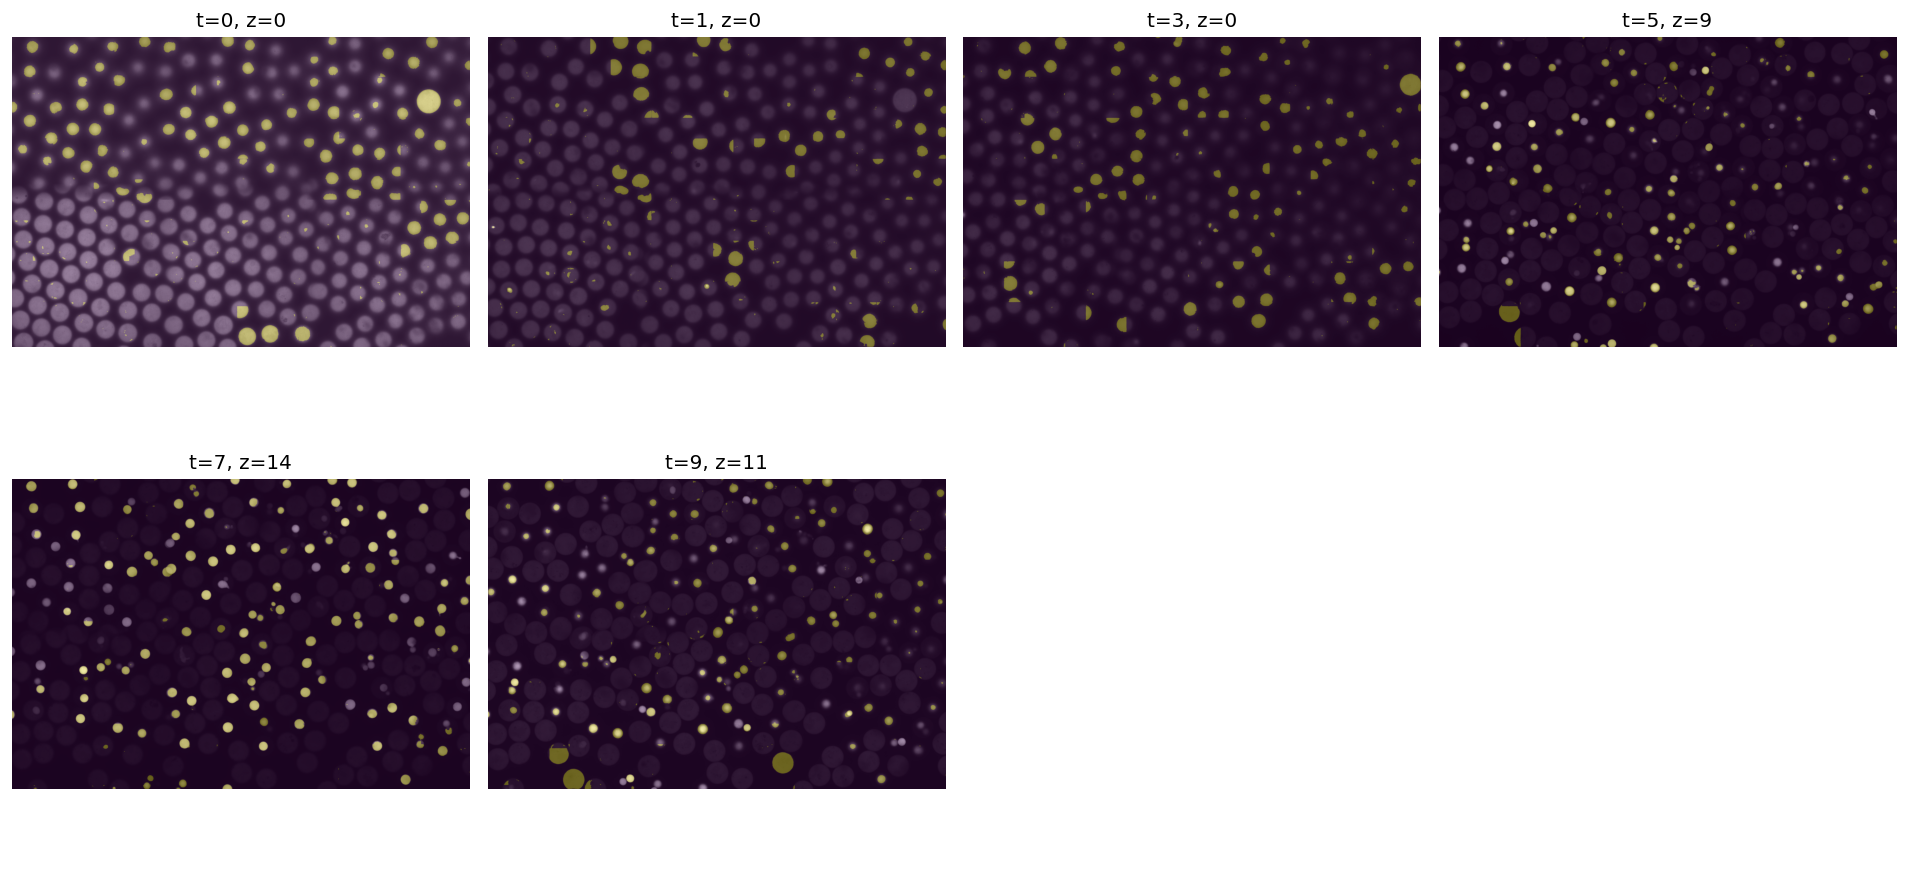

In [13]:

# Example overlay call if raw image is available:
if raw_img is not None and mask_arrays["nucleus_instance"] is not None:
    plot_raw_and_mask_overlay(
        raw_5d=raw_img,
        mask_4d=mask_arrays["nucleus_instance"],
        channel_index=int(config.get("nuclear_channel_index", 1)),
        z_mode="max_mask"
    )
else:
    print("Skipping overlay plot because raw image or nucleus instance mask is missing.")

## 10. Napari viewer

This viewer will try to load:

- raw image (if you supplied `RAW_IMAGE_PATH`)
- segmentation class labels
- segmentation connected-component labels
- nucleus instance labels
- droplet instance labels
- probability map, if it exists
- point layers from the exported tables

In [ ]:

def table_to_napari_points(df: pd.DataFrame, use_best_z_only=True):
    if df is None or df.empty:
        return None, None

    required = {"t", "z", "centroid_y_px", "centroid_x_px"}
    if not required.issubset(df.columns):
        return None, None

    pts_df = df.copy()
    if use_best_z_only and "best_z" in pts_df.columns and "z" in pts_df.columns:
        pts_df = pts_df[pts_df["z"] == pts_df["best_z"]]

    points = pts_df[["t", "z", "centroid_y_px", "centroid_x_px"]].to_numpy(dtype=float)
    return points, pts_df

def open_portable_bundle_in_napari(
    raw_img=None,
    seg_class=None,
    seg_label=None,
    nucleus_instance=None,
    droplet_instance=None,
    prob_map=None,
    best_z_df=None,
    tracked_df=None,
    halo_df=None,
):
    try:
        import napari
    except ImportError:
        print("napari is not installed in this environment.")
        print("Install with: pip install napari[all]")
        return None

    viewer = napari.Viewer()

    if raw_img is not None:
        viewer.add_image(raw_img, name="raw_image")

    if prob_map is not None:
        viewer.add_image(prob_map, name="segmentation_probability")

    if seg_class is not None:
        viewer.add_labels(seg_class.astype(np.int32), name="segmentation_class")

    if seg_label is not None:
        viewer.add_labels(seg_label.astype(np.int32), name="segmentation_label")

    if nucleus_instance is not None:
        viewer.add_labels(nucleus_instance.astype(np.int32), name="nucleus_instance")

    if droplet_instance is not None:
        viewer.add_labels(droplet_instance.astype(np.int32), name="droplet_instance")

    best_points, best_props = table_to_napari_points(best_z_df, use_best_z_only=False)
    if best_points is not None:
        viewer.add_points(
            best_points,
            name="best_z_centroids",
            size=8,
            properties={c: best_props[c].to_numpy() for c in best_props.columns if c not in ["centroid_x_px", "centroid_y_px"]},
        )

    tracked_points, tracked_props = table_to_napari_points(tracked_df, use_best_z_only=False)
    if tracked_points is not None:
        viewer.add_points(
            tracked_points,
            name="tracked_centroids",
            size=10,
            properties={c: tracked_props[c].to_numpy() for c in tracked_props.columns if c not in ["centroid_x_px", "centroid_y_px"]},
        )

    return viewer

In [ ]:

if AUTO_OPEN_NAPARI:
    viewer = open_portable_bundle_in_napari(
        raw_img=raw_img,
        seg_class=mask_arrays["segmentation_class"],
        seg_label=mask_arrays["segmentation_label"],
        nucleus_instance=mask_arrays["nucleus_instance"],
        droplet_instance=mask_arrays["droplet_instance"],
        prob_map=mask_arrays["segmentation_prob"],
        best_z_df=best_z_df,
        tracked_df=tracked_df,
        halo_df=halo_df,
    )

## 11. Useful one-liners

Uncomment what you need.

In [ ]:

# Open napari manually
# viewer = open_portable_bundle_in_napari(
#     raw_img=raw_img,
#     seg_class=mask_arrays["segmentation_class"],
#     seg_label=mask_arrays["segmentation_label"],
#     nucleus_instance=mask_arrays["nucleus_instance"],
#     droplet_instance=mask_arrays["droplet_instance"],
#     prob_map=mask_arrays["segmentation_prob"],
#     best_z_df=best_z_df,
#     tracked_df=tracked_df,
# )

# Inspect one table in detail
# display(halo_df.sort_values(["track_id", "true_time_min"]))

# Save a quick filtered CSV locally
# halo_df.query("nucleus_area_um2 > 100").to_csv("filtered_halo_analysis.csv", index=False)

## 12. Interpretation notes

### ROI handling
The exported **instance masks** act as your ROI layer in napari:
- `nucleus_instance_hyperstack.tif`
- `droplet_instance_hyperstack.tif`

Each non-zero integer is a unique object label.

### Probability maps
If a probability hyperstack was exported later, this notebook will detect it automatically as:
- `segmentation_prob_hyperstack.tif`
- or `probability_hyperstack.tif`

If neither exists, the napari viewer simply skips that layer.